# N3 Slinky Hessian Regularization vs Max `dλ`

This notebook runs the regularization ablation for the 3-node simulated slinky using the base training settings from `run_architectures_N3_slinky_sim_all.ipynb`. It trains models across Hessian regularizer strengths, evaluates the largest stable inference continuation step, computes Hessian diagnostics, and saves paper-ready summary plots.

In [1]:
import json
import os
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

jax.config.update("jax_enable_x64", True)
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

from properties import SlinkyN3Properties
from run_architectures import SweepConfig, subset_all
from run_hessian_reg_max_dlambda_experiment import build_arg_parser, run_experiment

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "hessian_reg_max_dlambda_outputs_n3_slinky_sim"
FIGURE_DIR = OUTPUT_DIR / "paper_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Copied from run_architectures_N3_slinky_sim_all.ipynb
train_file = "../simulation_data_2D/3_noded/n3_slinky_sim_train_dataset_7_trajs.npz"
valid_file = "../simulation_data_2D/3_noded/n3_slinky_sim_test_dataset_6_trajs.npz"
properties = SlinkyN3Properties()
K_init_chol = (0.02, 0.0, 0.05)
K_init_diag = (0.02, 0.05)

base_cfg = SweepConfig(
    der_K_diag=K_init_diag,
    der_K_chol=K_init_chol,
    hidden=(10, 10),
    corr_factor=0.05,
    input_mode="invariant",
    only_stretching_NN=True,
    only_bending_NN=False,
    zero_reference=True,
    activation="tanh",
    n_epochs=250,
    lr=5e-2,
    seed=42,
    valid_every=1,
    max_dlambda=1e-2,
    iters=10,
    ls_steps=10,
    abs_tol=1e-4,
    rel_tol=1e-4,
    early_stop=True,
    train_fail_on_nonconvergence=False,
    prediction_fail_on_nonconvergence=False,
    hessian_reg_strength=1e-4,
    hessian_reg_probes=1,
    hessian_reg_seed=0,
    force_key="F",
    force_loss_strength=0.1,
    force_components=(0,),
    force_sign=1.0,
    return_loss_components=True,
    early_stopping=True,
    early_stopping_patience=200,
    early_stopping_min_delta=1e-5,
    restore_best_model=True,
    output_dir=str(OUTPUT_DIR),
    save_npz=True,
    save_model=True,
    save_plots=True,
    save_force_predictions=True,
    plot_force_predictions=True,
    save_hessian_diagnostics=False,
    save_energy_landscapes=False,
    verbose=True,
    continue_on_failure=True,
)

print(f"Output dir: {OUTPUT_DIR.resolve()}")

Output dir: /Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/hessian_reg_max_dlambda_outputs_n3_slinky_sim


## Ablation Grid

`TRAIN_MAX_DLAMBDA_FOR_ABLATION` is intentionally conservative to isolate post-training solver robustness. Set it to `base_cfg.max_dlambda` if you want to train under the exact previous continuation step.

In [2]:
RUN_EXPERIMENT = True

SELECTED_ARCHITECTURES = (
    # "diag_energy_baseline",
    # "icnn_energy",
    # "diag_stiffness_mlp",
    "mlp_energy",
    # "chol_stiffness_mlp",
)

# For the full architecture set instead, uncomment:
# SELECTED_ARCHITECTURES = tuple(subset_all())

SEEDS = (0,)
HESSIAN_REG_STRENGTHS = (0.0, 1e-8, 1e-6, 1e-4)
EVAL_MAX_DLAMBDA_VALUES = (1e-3, 1e-2, 1e-1, 1.0)
TRAIN_MAX_DLAMBDA_FOR_ABLATION = 1e-2

print("Architectures:", SELECTED_ARCHITECTURES)
print("Seeds:", SEEDS)
print("Hessian regularizers:", HESSIAN_REG_STRENGTHS)
print("Eval max_dlambda values:", EVAL_MAX_DLAMBDA_VALUES)
print("Train max_dlambda:", TRAIN_MAX_DLAMBDA_FOR_ABLATION)

Architectures: ('mlp_energy',)
Seeds: (0,)
Hessian regularizers: (0.0, 1e-08, 1e-06, 0.0001)
Eval max_dlambda values: (0.001, 0.01, 0.1, 1.0)
Train max_dlambda: 0.01


In [ ]:
def csv(values):
    return ",".join(str(v) for v in values)

argv = [
    "--properties-class", "SlinkyN3Properties",
    "--train-file", train_file,
    "--valid-file", valid_file,
    "--architectures", csv(SELECTED_ARCHITECTURES),
    "--seeds", csv(SEEDS),
    "--hessian-reg-strengths", csv(HESSIAN_REG_STRENGTHS),
    "--eval-max-dlambda-values", csv(EVAL_MAX_DLAMBDA_VALUES),
    "--train-max-dlambda", str(TRAIN_MAX_DLAMBDA_FOR_ABLATION),
    "--output-dir", str(OUTPUT_DIR),
    "--der-k-diag", csv(base_cfg.der_K_diag),
    "--der-k-chol", csv(base_cfg.der_K_chol),
    "--hidden", csv(base_cfg.hidden),
    "--corr-factor", str(base_cfg.corr_factor),
    "--input-mode", base_cfg.input_mode,
    "--activation", base_cfg.activation,
    "--n-epochs", str(base_cfg.n_epochs),
    "--lr", str(base_cfg.lr),
    "--valid-every", str(base_cfg.valid_every),
    "--iters", str(base_cfg.iters),
    "--ls-steps", str(base_cfg.ls_steps),
    "--abs-tol", str(base_cfg.abs_tol),
    "--rel-tol", str(base_cfg.rel_tol),
    "--hessian-reg-probes", str(base_cfg.hessian_reg_probes),
    "--hessian-reg-seed", str(base_cfg.hessian_reg_seed),
    "--hessian-max-trajectories", "1",
    "--hessian-stride", "10",
    "--force-key", base_cfg.force_key,
    "--force-loss-strength", str(base_cfg.force_loss_strength),
    "--force-components", csv(base_cfg.force_components),
    "--force-sign", str(base_cfg.force_sign),
    "--early-stopping-patience", str(base_cfg.early_stopping_patience),
    "--early-stopping-min-delta", str(base_cfg.early_stopping_min_delta),
    "--no-plots",
]
if base_cfg.only_stretching_NN:
    argv.append("--only-stretching-nn")
if base_cfg.only_bending_NN:
    argv.append("--only-bending-nn")
if not base_cfg.zero_reference:
    argv.append("--no-zero-reference")
if not base_cfg.early_stop:
    argv.append("--no-early-stop")
if not base_cfg.train_fail_on_nonconvergence:
    argv.append("--train-allow-nonconvergence")
if base_cfg.return_loss_components:
    argv.append("--return-loss-components")
if not base_cfg.early_stopping:
    argv.append("--no-early-stopping")
if not base_cfg.restore_best_model:
    argv.append("--no-restore-best-model")

args = build_arg_parser().parse_args(argv)
if RUN_EXPERIMENT:
    records = run_experiment(args)
else:
    print("RUN_EXPERIMENT=False; skipping training/evaluation.")


[train] arch=mlp_energy seed=0 hreg=0 train_max_dlambda=0.01
Running architecture: mlp_energy
  model_cls               : ScalarEnergyNN
  which_case              : MLP
  hidden                  : (10, 10)
  input_mode              : invariant
  only_stretching_NN      : True
  only_bending_NN         : False
  activation              : tanh
  corr_factor             : 0.05
  zero_reference          : True
  seed                    : 0
  n_epochs                : 250
  lr                      : 0.05
  weight_decay            : 0.0
  max_dlambda             : 0.01
  iters                   : 10
  ls_steps                : 10
  abs_tol                 : 0.0001
  rel_tol                 : 0.0001
  early_stop              : True
  training fail_on_nonconvergence       : False
  validation loss fail_on_nonconvergence: False
  prediction fail_on_nonconvergence     : False
  early_stopping          : True
  early_stopping_patience : 200
  restore_best_model      : True
  hessian_reg_strength

## Load Summary Tables

In [ ]:
summary_path = OUTPUT_DIR / "summary.csv"
progress_path = OUTPUT_DIR / "progress.jsonl"

summary = pd.read_csv(summary_path)
with open(progress_path) as f:
    progress = [json.loads(line) for line in f if line.strip()]

eval_rows = []
for rec in progress:
    for item in rec.get("eval_by_max_dlambda", []):
        eval_rows.append({
            "arch_name": rec["arch_name"],
            "seed": rec["seed"],
            "hessian_reg_strength": rec["hessian_reg_strength"],
            "eval_max_dlambda": item["max_dlambda"],
            "success": bool(item["success"]),
            "valid_displacement_mse": item.get("valid_displacement_mse", np.nan),
        })
eval_df = pd.DataFrame(eval_rows)

display(summary.head())
display(eval_df.head())

,arch_name,seed,hessian_reg_strength,train_success,failure_reason,train_max_dlambda,largest_stable_eval_max_dlambda,best_eval_valid_displacement_mse,final_train_loss,final_valid_loss,...,kappa_hat,L_adj_hat,sigma_min_min,sigma_max_max,lambda_min_min,lambda_max_max,negative_min_eig_fraction,n_states,n_adjacent_pairs,exp_dir
0,diag_stiffness_mlp,0,0.000000e+00,True,NaN,0.01,1.0,0.002288,25.459243,18.870371,...,5.514738,259.687305,22.522564,140.313633,22.522564,140.313633,0.0,15,14,/Users/radha/GitRepos/dismech-jax/examples/sli...
1,diag_stiffness_mlp,0,1.000000e-08,True,NaN,0.01,1.0,0.002288,25.459372,18.870370,...,5.514739,259.687320,22.522560,140.313633,22.522560,140.313633,0.0,15,14,/Users/radha/GitRepos/dismech-jax/examples/sli...
2,diag_stiffness_mlp,0,1.000000e-06,True,NaN,0.01,1.0,0.002288,25.472192,18.870346,...,5.514783,259.688553,22.522263,140.313627,22.522263,140.313627,0.0,15,14,/Users/radha/GitRepos/dismech-jax/examples/sli...
3,diag_stiffness_mlp,0,1.000000e-04,True,NaN,0.01,1.0,0.002288,26.754562,18.868295,...,5.515012,259.679014,22.519954,140.314244,22.519954,140.314244,0.0,15,14,/Users/radha/GitRepos/dismech-jax/examples/sli...


,arch_name,seed,hessian_reg_strength,eval_max_dlambda,success,valid_displacement_mse
0,diag_energy_baseline,0,0.0,0.0005,True,0.016177
1,diag_energy_baseline,0,0.0,0.0010,True,0.016177
2,diag_energy_baseline,0,0.0,0.0050,True,0.016177
3,diag_energy_baseline,0,0.0,0.0100,True,0.016177
4,diag_energy_baseline,0,0.0,0.0500,True,0.016177


## Paper Figure Panels

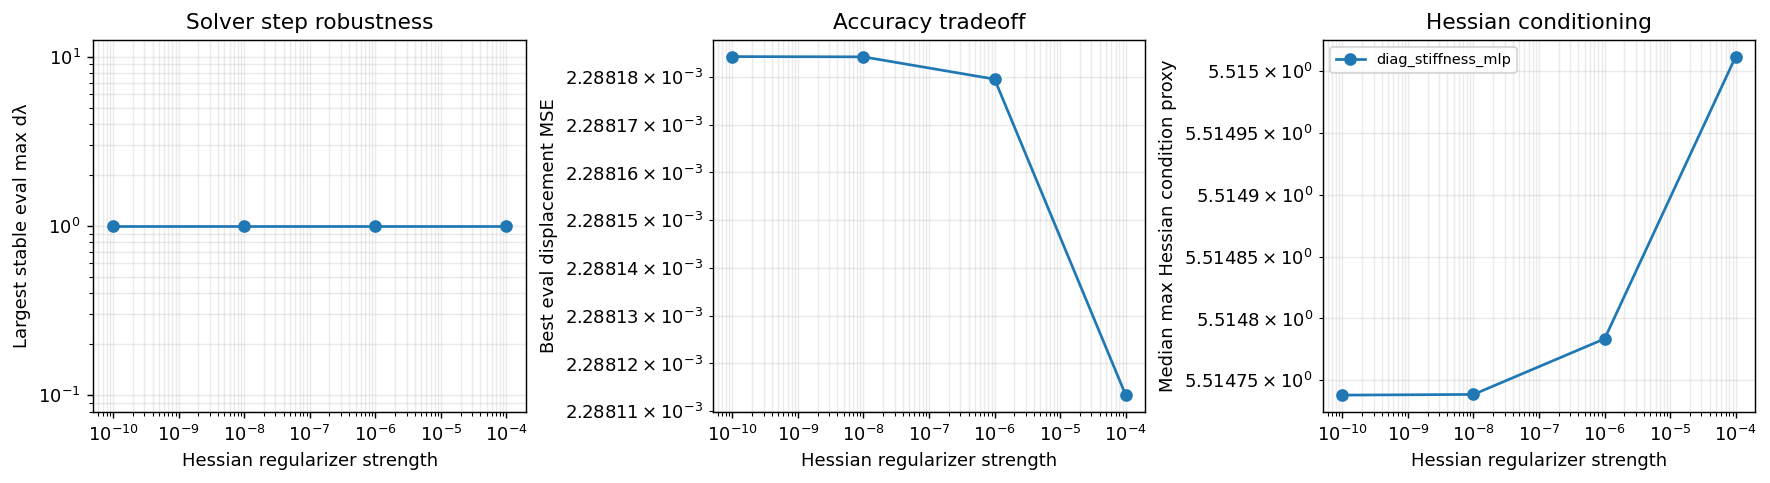

In [ ]:
plt.rcParams.update({"font.size": 10, "figure.dpi": 130})

plot_df = summary[summary["train_success"] == True].copy()
plot_df["hreg_plot"] = plot_df["hessian_reg_strength"].replace(0.0, 1e-10)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), constrained_layout=True)

for arch, group in plot_df.groupby("arch_name"):
    agg = group.groupby("hreg_plot")["largest_stable_eval_max_dlambda"].agg(["mean", "std"]).reset_index()
    axes[0].errorbar(agg["hreg_plot"], agg["mean"], yerr=agg["std"], marker="o", capsize=3, label=arch)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Hessian regularizer strength")
axes[0].set_ylabel("Largest stable eval max dλ")
axes[0].set_title("Solver step robustness")
axes[0].grid(True, which="both", alpha=0.25)

for arch, group in plot_df.groupby("arch_name"):
    agg = group.groupby("hreg_plot")["best_eval_valid_displacement_mse"].agg(["mean", "std"]).reset_index()
    axes[1].errorbar(agg["hreg_plot"], agg["mean"], yerr=agg["std"], marker="o", capsize=3, label=arch)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Hessian regularizer strength")
axes[1].set_ylabel("Best eval displacement MSE")
axes[1].set_title("Accuracy tradeoff")
axes[1].grid(True, which="both", alpha=0.25)

for arch, group in plot_df.groupby("arch_name"):
    agg = group.groupby("hreg_plot")["kappa_hat"].agg(["median"]).reset_index()
    axes[2].plot(agg["hreg_plot"], agg["median"], marker="o", label=arch)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("Hessian regularizer strength")
axes[2].set_ylabel("Median max Hessian condition proxy")
axes[2].set_title("Hessian conditioning")
axes[2].grid(True, which="both", alpha=0.25)

axes[2].legend(loc="best", fontsize=8)
fig.savefig(FIGURE_DIR / "n3_hessian_reg_ablation_panels.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "n3_hessian_reg_ablation_panels.png", bbox_inches="tight")
plt.show()

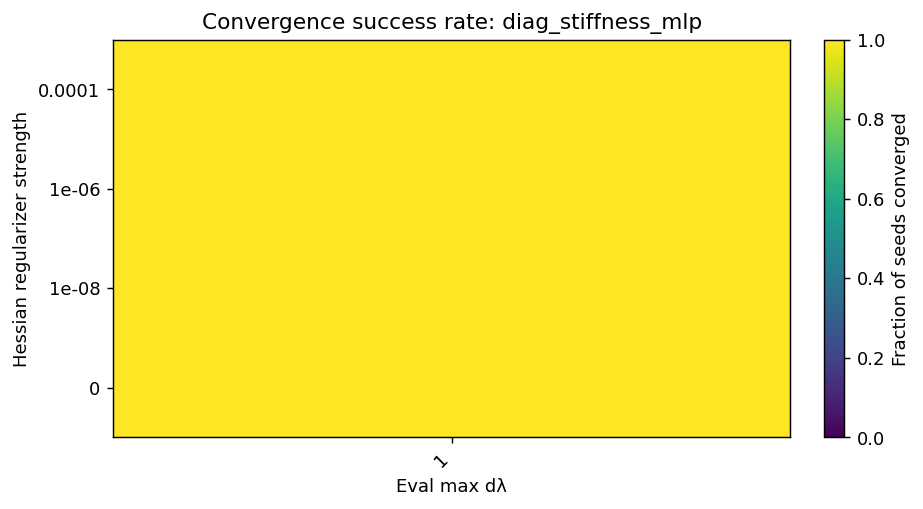

In [ ]:
success_rate = (
    eval_df.groupby(["arch_name", "hessian_reg_strength", "eval_max_dlambda"])["success"]
    .mean()
    .reset_index()
)

for arch in SELECTED_ARCHITECTURES:
    arch_df = success_rate[success_rate["arch_name"] == arch]
    if arch_df.empty:
        continue
    heat = arch_df.pivot(index="hessian_reg_strength", columns="eval_max_dlambda", values="success")
    fig, ax = plt.subplots(figsize=(7.0, 3.8), constrained_layout=True)
    im = ax.imshow(heat.values, aspect="auto", origin="lower", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels([f"{v:g}" for v in heat.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels([f"{v:g}" for v in heat.index])
    ax.set_xlabel("Eval max dλ")
    ax.set_ylabel("Hessian regularizer strength")
    ax.set_title(f"Convergence success rate: {arch}")
    fig.colorbar(im, ax=ax, label="Fraction of seeds converged")
    fig.savefig(FIGURE_DIR / f"n3_success_heatmap_{arch}.pdf", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"n3_success_heatmap_{arch}.png", bbox_inches="tight")
    plt.show()